In [12]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

tickers = ["AAPL", "MSFT", "NVDA", "JPM", "GS", "XOM", "CAT", "PG", "WMT", "JNJ"]

[*********************100%***********************]  10 of 10 completed


Zannualizowana zmienność w latach 2024-2025 (%):
Ticker
NVDA    51.13
CAT     29.18
GS      28.61
AAPL    27.92
JPM     24.19
MSFT    22.20
WMT     21.73
XOM     21.38
JNJ     17.49
PG      17.07
dtype: float64


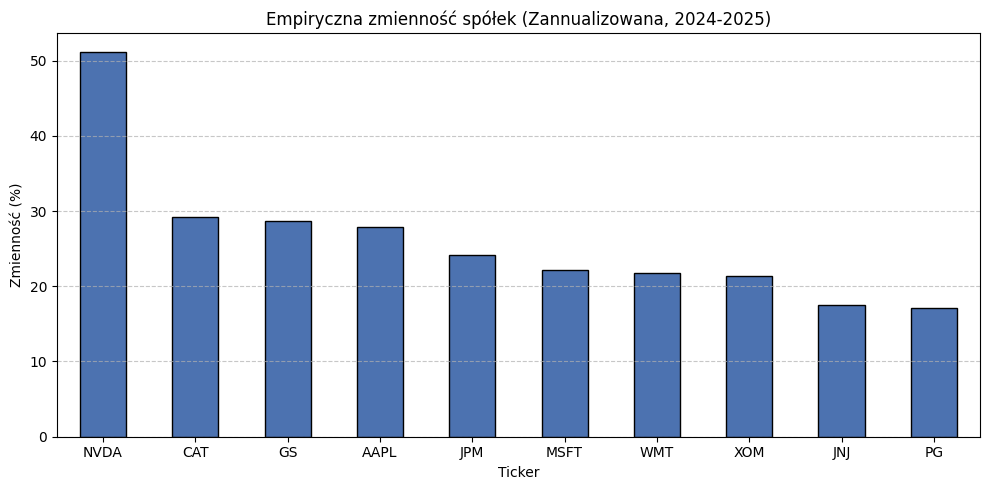

In [4]:
data = yf.download(tickers, start="2024-01-01", end="2025-12-31")['Close']

returns = data.pct_change().dropna()

volatility = returns.std() * np.sqrt(252) * 100 
volatility = volatility.sort_values(ascending=False)

print("Zannualizowana zmienność w latach 2024-2025 (%):")
print(volatility.round(2))

plt.figure(figsize=(10, 5))
volatility.plot(kind='bar', color='#4C72B0', edgecolor='black')
plt.title('Empiryczna zmienność spółek (Zannualizowana, 2024-2025)')
plt.ylabel('Zmienność (%)')
plt.xlabel('Ticker')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

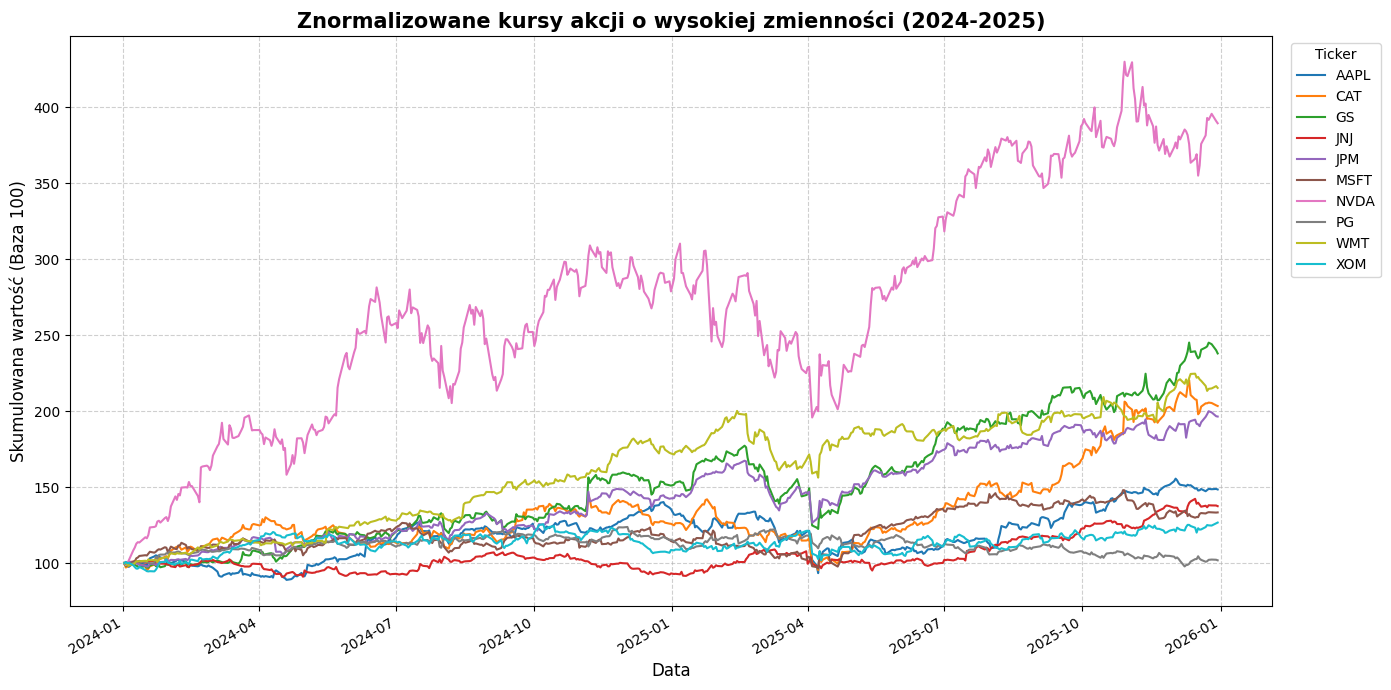

In [7]:
data = data.dropna(how='all')
data = data.ffill() 

# Normalizacja: (Cena bieżąca / Cena z pierwszego dnia) * 100
# Dzięki temu wszystkie linie startują dokładnie z tego samego punktu.
normalized_data = (data / data.iloc[0]) * 100

# Rysowanie wykresu wieloliniowego
plt.figure(figsize=(14, 7))
# Kolorowanie za pomocą wbudowanej mapy kolorów 'tab10' dla lepszego kontrastu
normalized_data.plot(ax=plt.gca(), linewidth=1.5, colormap='tab10')

plt.title('Znormalizowane kursy akcji o wysokiej zmienności (2024-2025)', fontsize=15, fontweight='bold')
plt.ylabel('Skumulowana wartość (Baza 100)', fontsize=12)
plt.xlabel('Data', fontsize=12)

# Przeniesienie legendy na zewnątrz wykresu, żeby nie zasłaniała gwałtownych skoków
plt.legend(title='Ticker', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.grid(axis='both', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

[*********************100%***********************]  8 of 8 completed

Zannualizowana zmienność w latach 2024-2025 (%):
Ticker
SMCI    104.21
MSTR     94.62
COIN     79.57
PLTR     65.74
TSLA     63.56
INTC     58.04
META     37.27
NFLX     31.85
dtype: float64


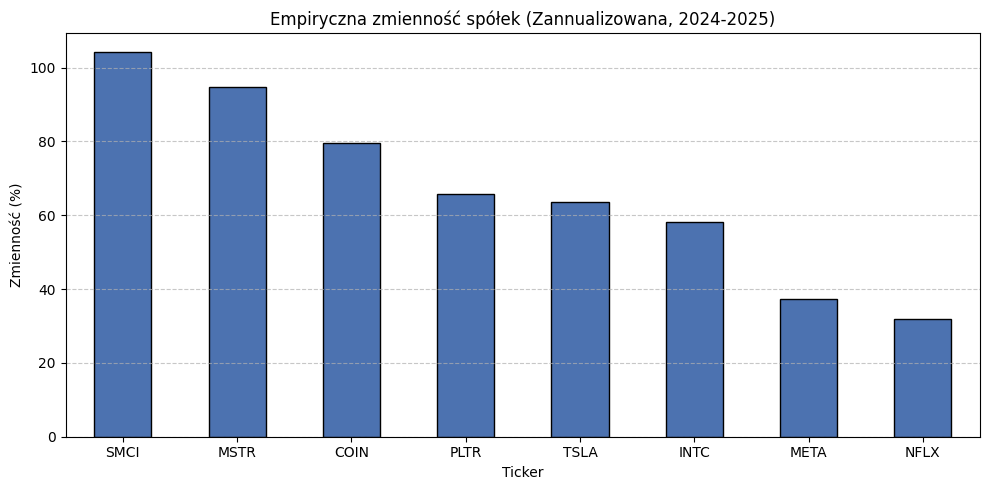

In [10]:
tickers = ["TSLA", "INTC", "COIN", "PLTR", "MSTR", "SMCI", "META", "NFLX"]

data = yf.download(tickers, start="2024-01-01", end="2025-12-31")['Close']

returns = data.pct_change().dropna()

volatility = returns.std() * np.sqrt(252) * 100 
volatility = volatility.sort_values(ascending=False)

print("Zannualizowana zmienność w latach 2024-2025 (%):")
print(volatility.round(2))

plt.figure(figsize=(10, 5))
volatility.plot(kind='bar', color='#4C72B0', edgecolor='black')
plt.title('Empiryczna zmienność spółek (Zannualizowana, 2024-2025)')
plt.ylabel('Zmienność (%)')
plt.xlabel('Ticker')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [17]:
if isinstance(data.columns, pd.MultiIndex):
    close = data["Close"][["META", "TSLA"]]
else:
    close = data[["META", "TSLA"]]

print(close.info())
print(close.isna().sum())
print(close[close.isna().any(axis=1)].head(20))

KeyError: "None of [Index(['META', 'TSLA'], dtype='object')] are in the [columns]"